In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os


dataset_name = 'mnist'

# Load dataset
if dataset_name == 'mnist':
    (x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
else:
    (x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize and reshape data
x_train = x_train.astype('float32') / 255.0
x_train = np.expand_dims(x_train, axis=-1)

# Parameters
BUFFER_SIZE = 60000
BATCH_SIZE = 128
NOISE_DIM = 100
EPOCHS = 50
EXAMPLES_TO_GENERATE = 16

# Prepare dataset
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# Generator
def make_generator_model():
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(NOISE_DIM,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

# Discriminator
def make_discriminator_model():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

# Losses and optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
generator = make_generator_model()
discriminator = make_discriminator_model()

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# Loss functions
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

# Training step
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# Generate and save images
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'generated_{dataset_name}_epoch_{epoch:03d}.png')
    plt.close()

# Training loop
seed = tf.random.normal([EXAMPLES_TO_GENERATE, NOISE_DIM])

def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        for image_batch in dataset:
            train_step(image_batch)
        print(f'Epoch {epoch} completed')
        generate_and_save_images(generator, epoch, seed)

# Start training
train(train_dataset, EPOCHS)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Epoch 30 completed
Epoch 31 completed
Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Epoch 40 completed
Epoch 41 completed
Epoch 42 completed
Epoch 43 completed
Epoch 44 completed
Epoch 45 completed
Epoch 46 completed
Epoch 47 completed
Epoch 48 completed
Epoch 49 completed
Epoch 50 completed


**TO-DO:**

Evaluate the GAN model:

-use t-SNE or UMAP to visualize the distribution of real vs generated image

-Measure image quality & diversity using Inception Score

-Calculate the Frechet Inception Distance

-Calculate the precision and recall for Generative Adversarial Network

-Calculate Disciminator Accuracy

-Plot Generator vs Discriminator Loss

-Repeat the same for fasion mnist dataset

-Repeat the same for non-grayscale dataset


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30 | G=0.8229 | D=0.9685 | ACC=0.7368
Epoch 2/30 | G=0.8916 | D=1.1979 | ACC=0.6896
Epoch 3/30 | G=1.0914 | D=1.0147 | ACC=0.7867
Epoch 4/30 | G=0.8685 | D=1.2391 | ACC=0.6758
Epoch 5/30 | G=0.8748 | D=1.2410 | ACC=0.6648
Epoch 6/30 | G=0.8444 | D=1.3015 | ACC=0.6281
Epoch 7/30 | G=0.8726 | D=1.2861 | ACC=0.6424
Epoch 8/30 | G=0.8538 | D=1.2702 | ACC=0.6373
Epoch 9/30 | G=0.8722 | D=1.2958 | ACC=0.6464
Epoch 10/30 | G=0.8751 | D=1.2453 | ACC=0.6618
Epoch 11/30 | G=0.9273 | D=1.2125 | ACC=0.6930
Epoch 12/30 | G=0.9758 | D=1.1828 | ACC=0.6972
Epoch 13/30 | G=1.0185 | D=1.1818 | ACC=0.6914
Epoch 14/30 | G=1.0006 | D=1.1779 | ACC=0.6924
Epoch 15/30 | G=1.0734 | D=1.1177 | ACC=0.7205
Epoch 16/30 | G=1.0686 | D=1.1171 | ACC=0.7186
Epoch 17/30 | G=1.1068 | D=1.0906 | ACC=0.7304
Epoch 18/30 | G=1.0941 | D=1.1013 | ACC=0.7224
Epoch 19/30 | G=1.1472 | D=1.0931 | ACC=0.7316
Epoch 20/30 | G=1.2038 | D=1.0543 | ACC=0.7388
Epoch 21/30 | G=1.2126 | D=1.0569 | ACC=0.7401
Epoch 22/30 | G=1.3242

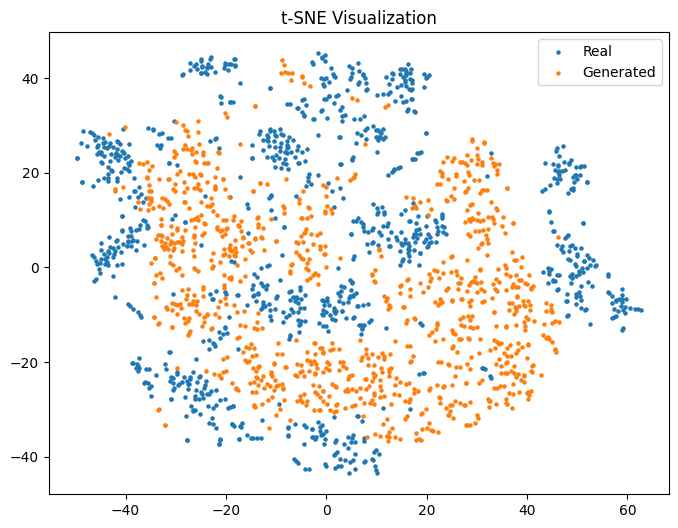

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


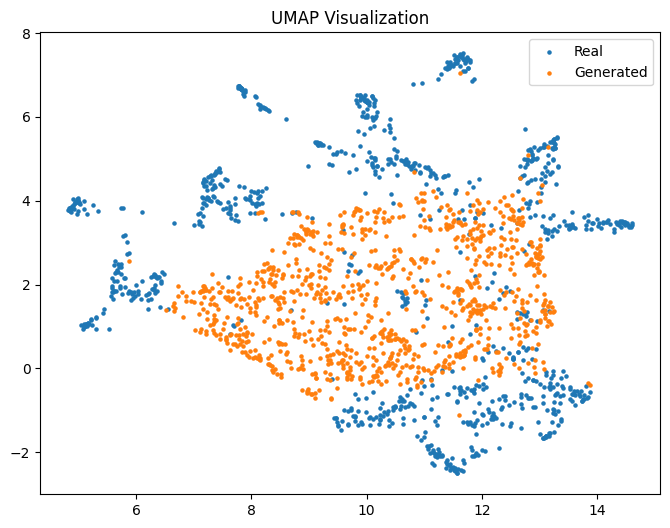


Precision: 0.842
Recall: 0.857

Final Discriminator Accuracy: 0.69431245


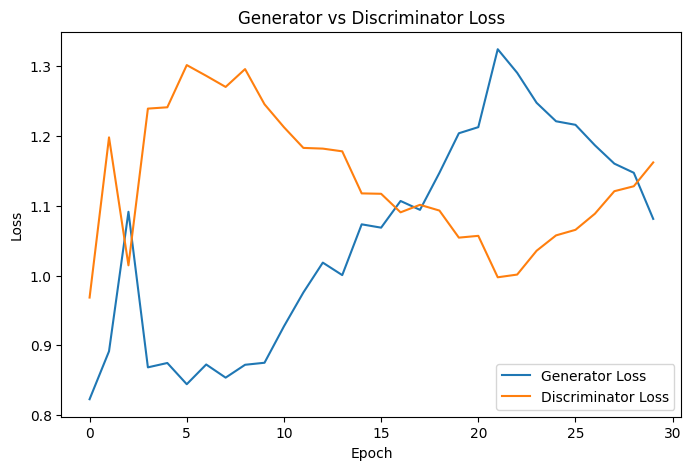

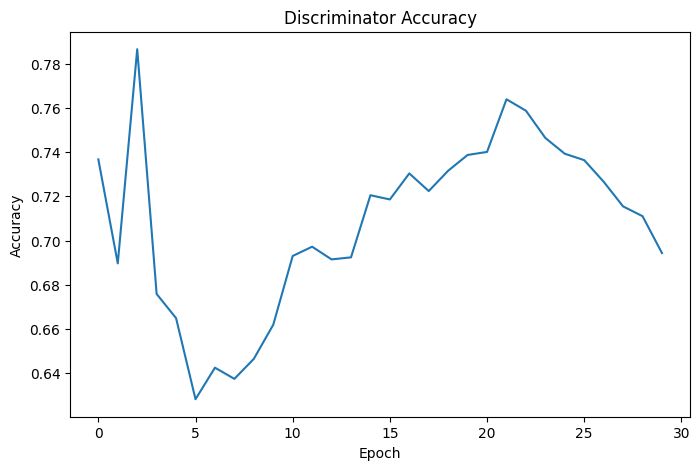

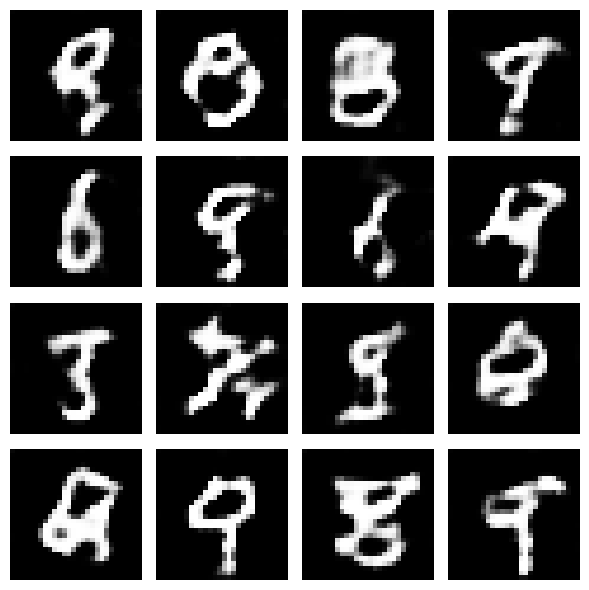


Evaluation Completed Successfully


In [ ]:
# ============================================================
# INSTALL PACKAGES
# ============================================================

!pip install -q umap-learn

# ============================================================
# IMPORTS
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import umap.umap_ as umap

# ============================================================
# PARAMETERS
# ============================================================

BUFFER_SIZE = 60000
BATCH_SIZE = 256
EPOCHS = 30
NOISE_DIM = 100
NUM_SAMPLES = 1000

# ============================================================
# LOAD MNIST
# ============================================================

(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()

train_images = train_images.reshape(
    train_images.shape[0], 28, 28, 1
).astype("float32")

train_images = (train_images - 127.5) / 127.5

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

# ============================================================
# GENERATOR
# ============================================================

def make_generator():

    model = tf.keras.Sequential()

    model.add(
        layers.Dense(
            7 * 7 * 256,
            use_bias=False,
            input_shape=(NOISE_DIM,)
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(
        layers.Conv2DTranspose(
            128,
            (5, 5),
            strides=(1, 1),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            1,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False,
            activation="tanh"
        )
    )

    return model

# ============================================================
# DISCRIMINATOR
# ============================================================

def make_discriminator():

    model = tf.keras.Sequential()

    model.add(
        layers.Conv2D(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            input_shape=[28, 28, 1]
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(
        layers.Conv2D(
            128,
            (5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

generator = make_generator()
discriminator = make_discriminator()

# ============================================================
# LOSS FUNCTIONS
# ============================================================

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

# ============================================================
# OPTIMIZERS
# ============================================================

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# ============================================================
# TRAIN STEP
# ============================================================

@tf.function
def train_step(images):

    noise = tf.random.normal(
        [tf.shape(images)[0], NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape,\
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    real_acc = tf.reduce_mean(
        tf.cast(real_output > 0, tf.float32)
    )

    fake_acc = tf.reduce_mean(
        tf.cast(fake_output < 0, tf.float32)
    )

    disc_acc = (real_acc + fake_acc) / 2

    return gen_loss, disc_loss, disc_acc

# ============================================================
# TRAINING
# ============================================================

gen_losses = []
disc_losses = []
disc_accuracies = []

for epoch in range(EPOCHS):

    g_losses = []
    d_losses = []
    d_accs = []

    for image_batch in train_dataset:

        g_loss, d_loss, d_acc = train_step(
            image_batch
        )

        g_losses.append(g_loss.numpy())
        d_losses.append(d_loss.numpy())
        d_accs.append(d_acc.numpy())

    gen_losses.append(np.mean(g_losses))
    disc_losses.append(np.mean(d_losses))
    disc_accuracies.append(np.mean(d_accs))

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"G={gen_losses[-1]:.4f} | "
        f"D={disc_losses[-1]:.4f} | "
        f"ACC={disc_accuracies[-1]:.4f}"
    )

# ============================================================
# GENERATE IMAGES
# ============================================================

noise = tf.random.normal(
    [NUM_SAMPLES, NOISE_DIM]
)

generated_images = generator(
    noise,
    training=False
).numpy()

real_images = train_images[:NUM_SAMPLES]

# ============================================================
# t-SNE
# ============================================================

real_flat = real_images.reshape(NUM_SAMPLES, -1)
fake_flat = generated_images.reshape(NUM_SAMPLES, -1)

combined = np.vstack(
    [real_flat, fake_flat]
)

tsne = TSNE(
    n_components=2,
    random_state=42
)

embedding = tsne.fit_transform(combined)

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[:NUM_SAMPLES,0],
    embedding[:NUM_SAMPLES,1],
    s=5,
    label="Real"
)

plt.scatter(
    embedding[NUM_SAMPLES:,0],
    embedding[NUM_SAMPLES:,1],
    s=5,
    label="Generated"
)

plt.legend()
plt.title("t-SNE Visualization")
plt.show()

# ============================================================
# UMAP
# ============================================================

reducer = umap.UMAP(random_state=42)

embedding = reducer.fit_transform(combined)

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[:NUM_SAMPLES,0],
    embedding[:NUM_SAMPLES,1],
    s=5,
    label="Real"
)

plt.scatter(
    embedding[NUM_SAMPLES:,0],
    embedding[NUM_SAMPLES:,1],
    s=5,
    label="Generated"
)

plt.legend()
plt.title("UMAP Visualization")
plt.show()

# ============================================================
# PRECISION & RECALL
# ============================================================

distances = pairwise_distances(
    real_flat,
    fake_flat
)

threshold = np.percentile(
    distances,
    5
)

precision = np.mean(
    np.min(distances, axis=0) < threshold
)

recall = np.mean(
    np.min(distances, axis=1) < threshold
)

print("\nPrecision:", precision)
print("Recall:", recall)

# ============================================================
# DISCRIMINATOR ACCURACY
# ============================================================

print(
    "\nFinal Discriminator Accuracy:",
    disc_accuracies[-1]
)

# ============================================================
# LOSS PLOT
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    gen_losses,
    label="Generator Loss"
)

plt.plot(
    disc_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Generator vs Discriminator Loss")
plt.show()

# ============================================================
# DISCRIMINATOR ACCURACY PLOT
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(disc_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Discriminator Accuracy")
plt.show()

# ============================================================
# SHOW GENERATED SAMPLES
# ============================================================

samples = generated_images[:16]

samples = (samples * 127.5 + 127.5).astype(np.uint8)

plt.figure(figsize=(6,6))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        samples[i,:,:,0],
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("\nEvaluation Completed Successfully")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30 | G=0.7053 | D=1.1964 | ACC=0.6900
Epoch 2/30 | G=0.8457 | D=1.2677 | ACC=0.6831
Epoch 3/30 | G=0.8373 | D=1.2789 | ACC=0.6614
Epoch 4/30 | G=0.7993 | D=1.3188 | ACC=0.6231
Epoch 5/30 | G=0.8486 | D=1.2722 | ACC=0.6479
Epoch 6/30 | G=0.8338 | D=1.3086 | ACC=0.6284
Epoch 7/30 | G=0.9042 | D=1.2699 | ACC=0.6580
Epoch 8/30 | G=0.8800 | D=1.2129 | ACC=0.6899
Epoch 9/30 | G=0.8392 | D=1.3105 | ACC=0.6132
Epoch 10/30 | G=0.8807 | D=1.2247 | ACC=0.6765
Epoch 11/30 | G=0.9169 | D=1.2231 | ACC=0.6732
Epoch 12/30 | G=0.9791 | D=1.1872 | ACC=0.7021
Epoch 13/30 | G=0.9852 | D=1.1544 | ACC=0.7157
Epoch 14/30 | G=1.0994 | D=1.1057 | ACC=0.7307
Epoch 15/30 | G=1.0755 | D=1.0736 | ACC=0.7449
Epoch 16/30 | G=1.1453 | D=1.0706 | ACC=0.7352
Epoch 17/30 | G=1.1573 | D=1.0052 | ACC=0.7721
Epoch 18/30 | G=1.2664 | D=0.9498 | ACC=0.7852
Epoch 19/30 | G=1.3757 | D=0.8838 | ACC=0.8059
Epoch 20/30 | G=1.4424 | D=0.8333 | ACC=0.8229
Epoch 21/30 | G=1.4969 | D=0.8425 | ACC=0.8147
Epoch 22/30 | G=1.5806

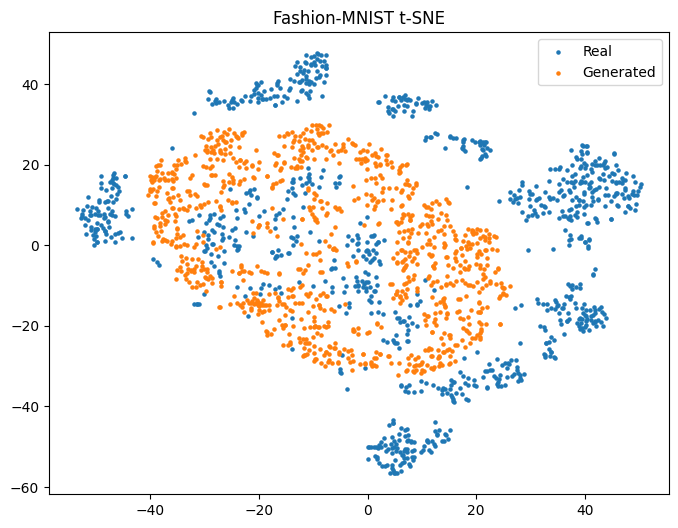

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


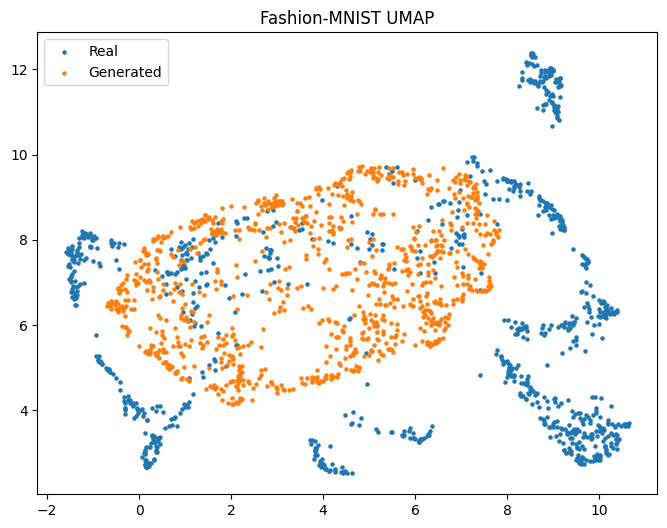


Precision : 0.914
Recall    : 0.578


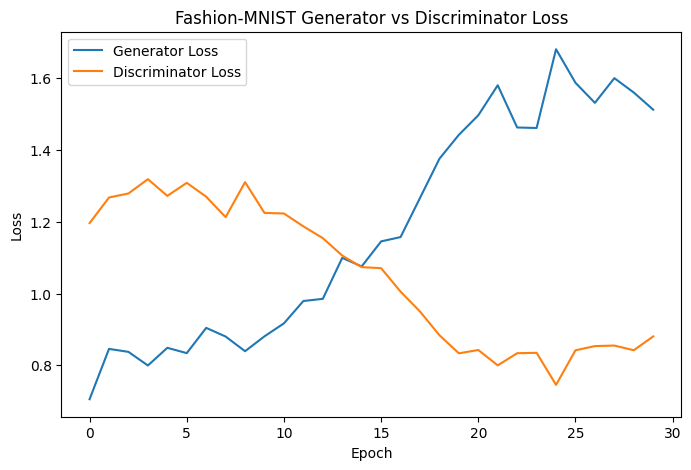

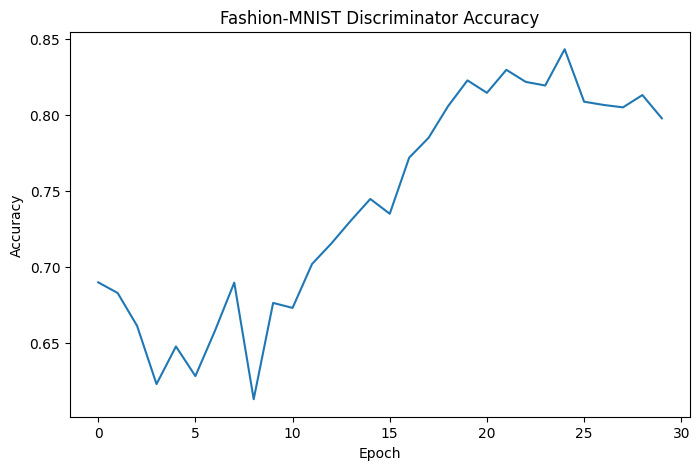


Final Discriminator Accuracy: 0.7979444


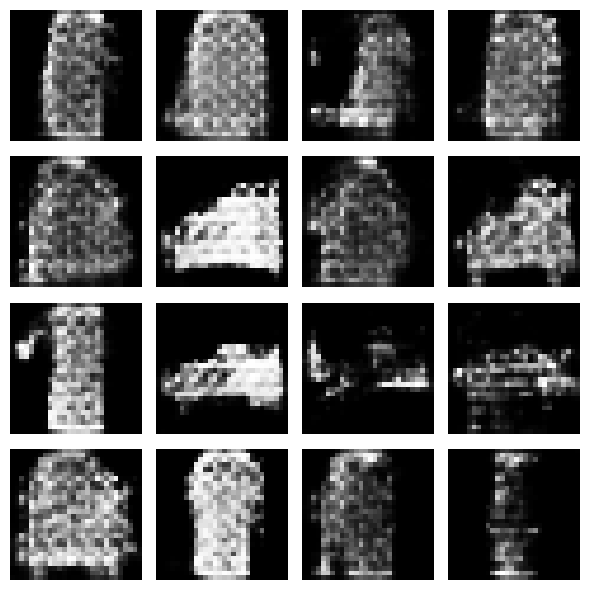


Fashion-MNIST Evaluation Completed Successfully


In [ ]:
# ============================================================
# INSTALL REQUIRED PACKAGES
# ============================================================

!pip install -q umap-learn

# ============================================================
# IMPORTS
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import umap.umap_ as umap

# ============================================================
# PARAMETERS
# ============================================================

BUFFER_SIZE = 60000
BATCH_SIZE = 256
EPOCHS = 30
NOISE_DIM = 100
NUM_SAMPLES = 1000

# ============================================================
# LOAD FASHION-MNIST
# ============================================================

(train_images, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

train_images = train_images.reshape(
    train_images.shape[0],
    28,
    28,
    1
).astype("float32")

train_images = (train_images - 127.5) / 127.5

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

# ============================================================
# GENERATOR
# ============================================================

def make_generator():

    model = tf.keras.Sequential()

    model.add(
        layers.Dense(
            7 * 7 * 256,
            use_bias=False,
            input_shape=(NOISE_DIM,)
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(
        layers.Conv2DTranspose(
            128,
            (5, 5),
            strides=(1, 1),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            1,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False,
            activation="tanh"
        )
    )

    return model

# ============================================================
# DISCRIMINATOR
# ============================================================

def make_discriminator():

    model = tf.keras.Sequential()

    model.add(
        layers.Conv2D(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            input_shape=[28, 28, 1]
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(
        layers.Conv2D(
            128,
            (5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

generator = make_generator()
discriminator = make_discriminator()

# ============================================================
# LOSS FUNCTIONS
# ============================================================

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

# ============================================================
# OPTIMIZERS
# ============================================================

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# ============================================================
# TRAIN STEP
# ============================================================

@tf.function
def train_step(images):

    noise = tf.random.normal(
        [tf.shape(images)[0], NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape,\
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gen_gradients,
            generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(disc_gradients,
            discriminator.trainable_variables)
    )

    real_acc = tf.reduce_mean(
        tf.cast(real_output > 0, tf.float32)
    )

    fake_acc = tf.reduce_mean(
        tf.cast(fake_output < 0, tf.float32)
    )

    disc_acc = (real_acc + fake_acc) / 2

    return gen_loss, disc_loss, disc_acc

# ============================================================
# TRAINING
# ============================================================

gen_losses = []
disc_losses = []
disc_accuracies = []

for epoch in range(EPOCHS):

    g_losses = []
    d_losses = []
    d_accs = []

    for image_batch in train_dataset:

        g_loss, d_loss, d_acc = train_step(
            image_batch
        )

        g_losses.append(g_loss.numpy())
        d_losses.append(d_loss.numpy())
        d_accs.append(d_acc.numpy())

    gen_losses.append(np.mean(g_losses))
    disc_losses.append(np.mean(d_losses))
    disc_accuracies.append(np.mean(d_accs))

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"G={gen_losses[-1]:.4f} | "
        f"D={disc_losses[-1]:.4f} | "
        f"ACC={disc_accuracies[-1]:.4f}"
    )

# ============================================================
# GENERATE IMAGES
# ============================================================

noise = tf.random.normal(
    [NUM_SAMPLES, NOISE_DIM]
)

generated_images = generator(
    noise,
    training=False
).numpy()

real_images = train_images[:NUM_SAMPLES]

# ============================================================
# t-SNE
# ============================================================

real_flat = real_images.reshape(NUM_SAMPLES,-1)
fake_flat = generated_images.reshape(NUM_SAMPLES,-1)

combined = np.vstack([real_flat,fake_flat])

tsne = TSNE(
    n_components=2,
    random_state=42
)

embedding = tsne.fit_transform(combined)

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[:NUM_SAMPLES,0],
    embedding[:NUM_SAMPLES,1],
    s=5,
    label="Real"
)

plt.scatter(
    embedding[NUM_SAMPLES:,0],
    embedding[NUM_SAMPLES:,1],
    s=5,
    label="Generated"
)

plt.legend()
plt.title("Fashion-MNIST t-SNE")
plt.show()

# ============================================================
# UMAP
# ============================================================

reducer = umap.UMAP(random_state=42)

embedding = reducer.fit_transform(combined)

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[:NUM_SAMPLES,0],
    embedding[:NUM_SAMPLES,1],
    s=5,
    label="Real"
)

plt.scatter(
    embedding[NUM_SAMPLES:,0],
    embedding[NUM_SAMPLES:,1],
    s=5,
    label="Generated"
)

plt.legend()
plt.title("Fashion-MNIST UMAP")
plt.show()

# ============================================================
# PRECISION & RECALL
# ============================================================

distances = pairwise_distances(
    real_flat,
    fake_flat
)

threshold = np.percentile(
    distances,
    5
)

precision = np.mean(
    np.min(distances,axis=0) < threshold
)

recall = np.mean(
    np.min(distances,axis=1) < threshold
)

print("\nPrecision :", precision)
print("Recall    :", recall)

# ============================================================
# LOSS PLOT
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    gen_losses,
    label="Generator Loss"
)

plt.plot(
    disc_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Fashion-MNIST Generator vs Discriminator Loss")
plt.show()

# ============================================================
# DISCRIMINATOR ACCURACY
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(disc_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fashion-MNIST Discriminator Accuracy")
plt.show()

print(
    "\nFinal Discriminator Accuracy:",
    disc_accuracies[-1]
)

# ============================================================
# SHOW GENERATED SAMPLES
# ============================================================

samples = generated_images[:16]

samples = (
    samples * 127.5 + 127.5
).astype(np.uint8)

plt.figure(figsize=(6,6))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        samples[i,:,:,0],
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("\nFashion-MNIST Evaluation Completed Successfully")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30 | G=1.0794 | D=0.9332 | ACC=0.7806
Epoch 2/30 | G=1.5167 | D=0.8790 | ACC=0.8353
Epoch 3/30 | G=1.8960 | D=0.5511 | ACC=0.9033
Epoch 4/30 | G=2.6309 | D=0.4392 | ACC=0.9241
Epoch 5/30 | G=2.2908 | D=0.6188 | ACC=0.8665
Epoch 6/30 | G=1.4117 | D=0.9021 | ACC=0.7978
Epoch 7/30 | G=1.7562 | D=0.6909 | ACC=0.8695
Epoch 8/30 | G=2.0302 | D=0.6525 | ACC=0.8703
Epoch 9/30 | G=1.7640 | D=0.8002 | ACC=0.8297
Epoch 10/30 | G=1.7093 | D=0.8527 | ACC=0.8232
Epoch 11/30 | G=1.6540 | D=0.7649 | ACC=0.8445
Epoch 12/30 | G=1.7954 | D=0.8299 | ACC=0.8168
Epoch 13/30 | G=1.6421 | D=0.8479 | ACC=0.8204
Epoch 14/30 | G=1.6324 | D=0.7956 | ACC=0.8336
Epoch 15/30 | G=1.7807 | D=0.7471 | ACC=0.8422
Epoch 16/30 | G=1.7193 | D=0.8045 | ACC=0.8318
Epoch 17/30 | G=1.6448 | D=0.8412 | ACC=0.8184
Epoch 18/30 | G=1.9370 | D=0.7388 | ACC=0.8436
Epoch 19/30 | G=1.5390 | D=0.9843 | ACC=0.7651
Epoch 20/30 | G=1.4483 | D=0.9616 | ACC=0.7763
Epoch 21/30 | G=1.4706 | D=0.9886 | ACC=0.7657
Epoch 22/30 | G=1.6252

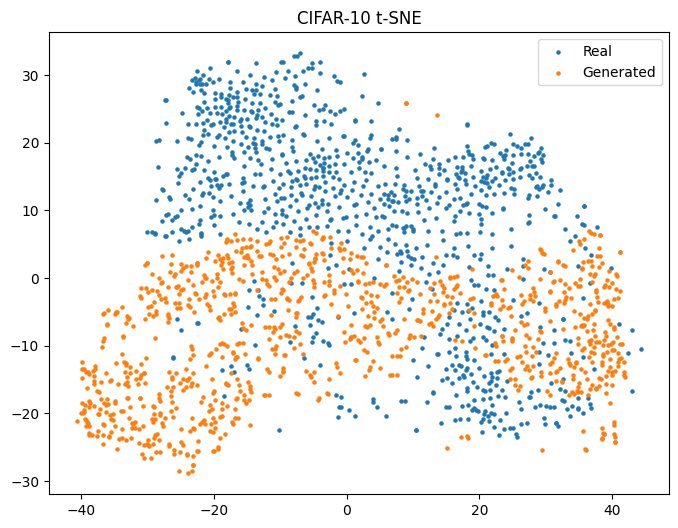

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


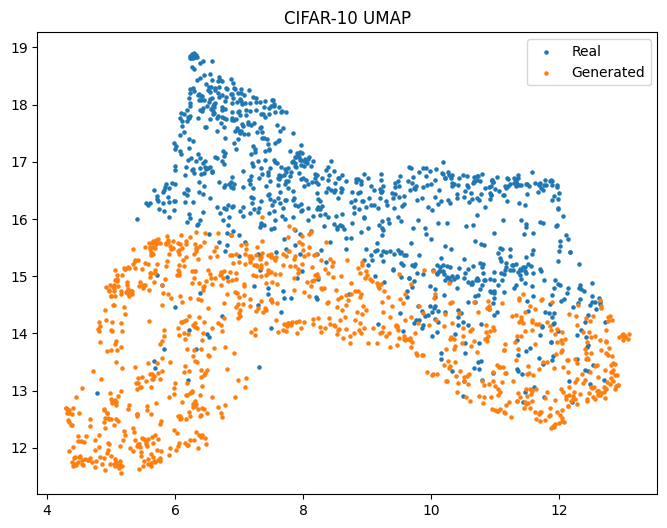


Precision : 0.814
Recall    : 0.697


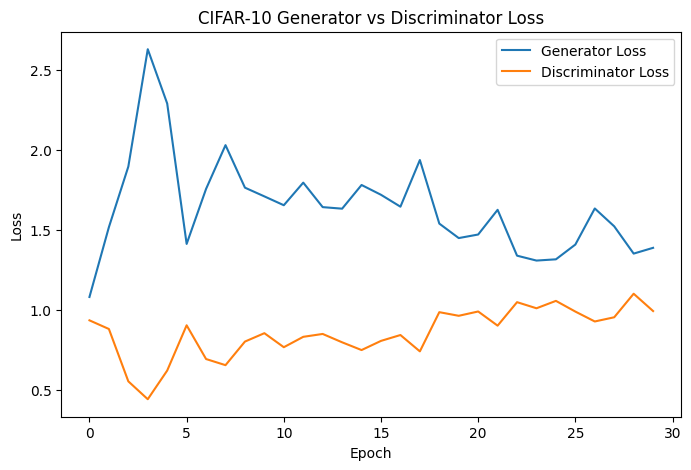

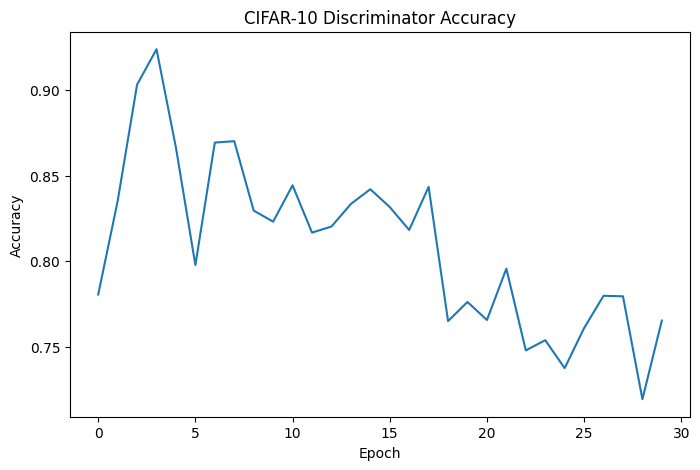


Final Discriminator Accuracy: 0.7654137


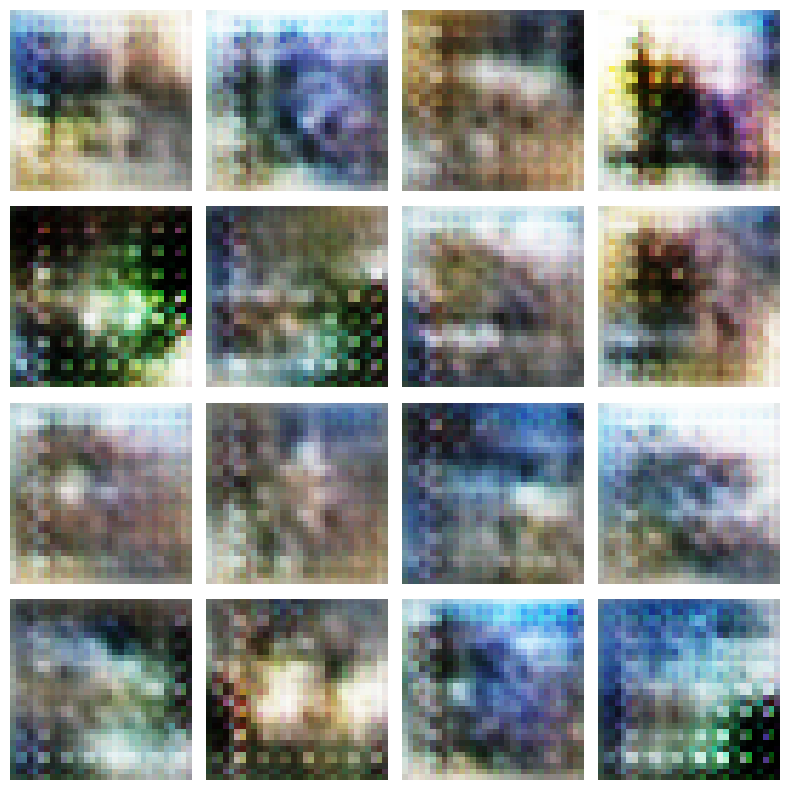


CIFAR-10 Evaluation Completed Successfully


In [ ]:
# ============================================================
# INSTALL REQUIRED PACKAGES
# ============================================================

!pip install -q umap-learn

# ============================================================
# IMPORTS
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import umap.umap_ as umap

# ============================================================
# PARAMETERS
# ============================================================

BUFFER_SIZE = 50000
BATCH_SIZE = 256
EPOCHS = 30
NOISE_DIM = 100
NUM_SAMPLES = 1000

# ============================================================
# LOAD CIFAR-10
# ============================================================

(train_images, _), (_, _) = tf.keras.datasets.cifar10.load_data()

train_images = train_images.astype("float32")
train_images = (train_images - 127.5) / 127.5

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

# ============================================================
# GENERATOR
# ============================================================

def make_generator():

    model = tf.keras.Sequential()

    model.add(
        layers.Dense(
            8 * 8 * 256,
            use_bias=False,
            input_shape=(NOISE_DIM,)
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))

    model.add(
        layers.Conv2DTranspose(
            128,
            (5,5),
            strides=(1,1),
            padding='same',
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            64,
            (5,5),
            strides=(2,2),
            padding='same',
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            3,
            (5,5),
            strides=(2,2),
            padding='same',
            use_bias=False,
            activation='tanh'
        )
    )

    return model

# ============================================================
# DISCRIMINATOR
# ============================================================

def make_discriminator():

    model = tf.keras.Sequential()

    model.add(
        layers.Conv2D(
            64,
            (5,5),
            strides=(2,2),
            padding='same',
            input_shape=[32,32,3]
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(
        layers.Conv2D(
            128,
            (5,5),
            strides=(2,2),
            padding='same'
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

generator = make_generator()
discriminator = make_discriminator()

# ============================================================
# LOSS FUNCTIONS
# ============================================================

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

# ============================================================
# OPTIMIZERS
# ============================================================

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# ============================================================
# TRAIN STEP
# ============================================================

@tf.function
def train_step(images):

    noise = tf.random.normal(
        [tf.shape(images)[0], NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape,\
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            discriminator.trainable_variables
        )
    )

    real_acc = tf.reduce_mean(
        tf.cast(real_output > 0, tf.float32)
    )

    fake_acc = tf.reduce_mean(
        tf.cast(fake_output < 0, tf.float32)
    )

    disc_acc = (real_acc + fake_acc) / 2

    return gen_loss, disc_loss, disc_acc

# ============================================================
# TRAINING
# ============================================================

gen_losses = []
disc_losses = []
disc_accuracies = []

for epoch in range(EPOCHS):

    g_losses = []
    d_losses = []
    d_accs = []

    for image_batch in train_dataset:

        g_loss, d_loss, d_acc = train_step(
            image_batch
        )

        g_losses.append(g_loss.numpy())
        d_losses.append(d_loss.numpy())
        d_accs.append(d_acc.numpy())

    gen_losses.append(np.mean(g_losses))
    disc_losses.append(np.mean(d_losses))
    disc_accuracies.append(np.mean(d_accs))

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"G={gen_losses[-1]:.4f} | "
        f"D={disc_losses[-1]:.4f} | "
        f"ACC={disc_accuracies[-1]:.4f}"
    )

# ============================================================
# GENERATE IMAGES
# ============================================================

noise = tf.random.normal(
    [NUM_SAMPLES, NOISE_DIM]
)

generated_images = generator(
    noise,
    training=False
).numpy()

real_images = train_images[:NUM_SAMPLES]

# ============================================================
# t-SNE
# ============================================================

real_flat = real_images.reshape(NUM_SAMPLES,-1)
fake_flat = generated_images.reshape(NUM_SAMPLES,-1)

combined = np.vstack([real_flat,fake_flat])

tsne = TSNE(
    n_components=2,
    random_state=42
)

embedding = tsne.fit_transform(combined)

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[:NUM_SAMPLES,0],
    embedding[:NUM_SAMPLES,1],
    s=5,
    label="Real"
)

plt.scatter(
    embedding[NUM_SAMPLES:,0],
    embedding[NUM_SAMPLES:,1],
    s=5,
    label="Generated"
)

plt.legend()
plt.title("CIFAR-10 t-SNE")
plt.show()

# ============================================================
# UMAP
# ============================================================

reducer = umap.UMAP(random_state=42)

embedding = reducer.fit_transform(combined)

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[:NUM_SAMPLES,0],
    embedding[:NUM_SAMPLES,1],
    s=5,
    label="Real"
)

plt.scatter(
    embedding[NUM_SAMPLES:,0],
    embedding[NUM_SAMPLES:,1],
    s=5,
    label="Generated"
)

plt.legend()
plt.title("CIFAR-10 UMAP")
plt.show()

# ============================================================
# PRECISION & RECALL
# ============================================================

distances = pairwise_distances(
    real_flat,
    fake_flat
)

threshold = np.percentile(
    distances,
    5
)

precision = np.mean(
    np.min(distances, axis=0) < threshold
)

recall = np.mean(
    np.min(distances, axis=1) < threshold
)

print("\nPrecision :", precision)
print("Recall    :", recall)

# ============================================================
# LOSS PLOT
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CIFAR-10 Generator vs Discriminator Loss")
plt.show()

# ============================================================
# DISCRIMINATOR ACCURACY
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(disc_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CIFAR-10 Discriminator Accuracy")
plt.show()

print(
    "\nFinal Discriminator Accuracy:",
    disc_accuracies[-1]
)

# ============================================================
# SHOW GENERATED RGB IMAGES
# ============================================================

samples = generated_images[:16]

samples = (
    samples * 127.5 + 127.5
).astype(np.uint8)

plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(samples[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

print("\nCIFAR-10 Evaluation Completed Successfully")